# Collapse of diversity under time-average neutral competition

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import repertoire_simulator.lib as lib


plt.style.use("../../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../../data/"

In [5]:
Ds = np.logspace(-1, 1, 10)
results_for_strength = {}
cs_final_for_strength = {}
for D in Ds:
    records = np.load(DATA_PATH + f"how_to_maintain_diversity/rem_transition/noise_strength_{D}.npz", allow_pickle=True)
    t = records['t']
    c_t = records['c']
    Seff = np.zeros(len(t))
    
    cs_final_for_strength[D] = c_t[50]
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
    
    results_for_strength[D] = {'t':t, 'Seff':Seff}

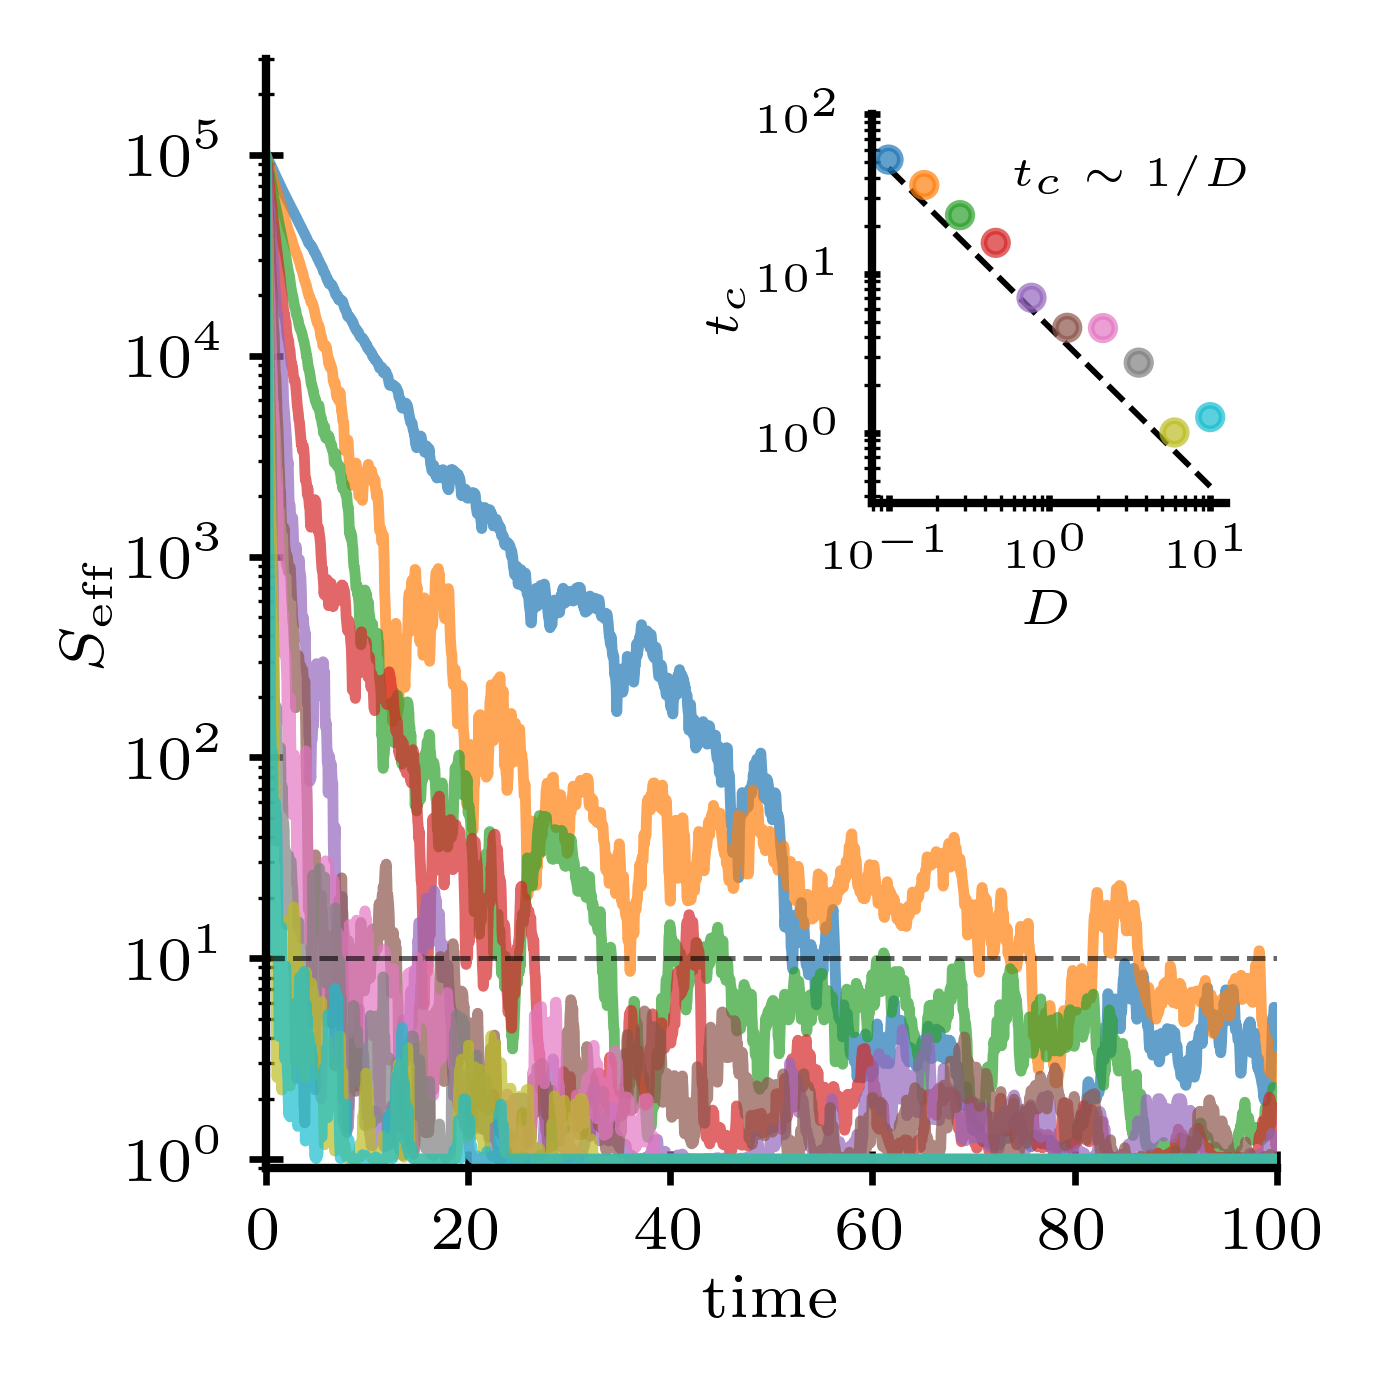

In [6]:
fig, ax = plt.subplots(figsize=(2.2, 2.2), layout='constrained')

Ds_arr = np.asarray(Ds)
t_cs = np.full(len(Ds_arr), np.nan)
colors = []

for i, D in enumerate(Ds_arr):
    t = results_for_strength[D]['t']
    Seff = results_for_strength[D]['Seff']

    line, = ax.plot(t, Seff, alpha=0.7)
    colors.append(line.get_color())

    below = np.where(Seff <= 10)[0]
    if len(below) > 0:
        t_cs[i] = t[below[0]]

ax.axhline(10, color='k', lw=0.6, ls='--', alpha=0.6)

ax.set_yscale('log')
ax.set_xlim(0, 100)
ax.set_ylim(0.9, 3e5)
ax.set_xlabel(r'time')
ax.set_ylabel(r'$S_{\mathrm{eff}}$')

inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])

mask = np.isfinite(t_cs)

inset.set_xscale('log')
inset.set_yscale('log')
inset.plot(Ds_arr, np.log(1e5 / 10) / (2*Ds_arr) , linestyle='--', c='black', lw=0.7, zorder=-2)
inset.text(0.4, 0.9, r'$t_c \sim 1/D$', transform=inset.transAxes, fontsize=5, ha='left',va='top')

inset.scatter(Ds_arr[mask],t_cs[mask], s=8, c=np.asarray(colors)[mask], alpha=0.7)

inset.set_ylim([None, 100])

inset.set_xlabel(r'$D$', fontsize=6)
inset.set_ylabel(r'$t_c$', fontsize=6)
inset.tick_params(axis='both', labelsize=5, length=2)
plt.savefig('../../figures/how_to_maintain_diversity/condensation.pdf', bbox_inches='tight', dpi=200, transparent=True);